# In-Class Assignment: Machine Learning; classification with logistic regression
# Day 15
# CMSE 202
<img src="https://i.ibb.co/vv36b1d/supervised-workflow-machine-learning.png" width=700px>


### Agenda for today's class

</p>

1. [Training vs Testing](#train-test)
2. [Logistic Regression](#logit)

### <p style="text-align: right;"> &#9989; **Jaehan Kim** </p>
#### <p style="text-align: right;"> &#9989; Akshita, Ahmed, Taliah</p>

## Imports for the day

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

----
<a id="train-test"></a>
## 1. Training vs Testing

As you learned in the pre-class, classification is an ML process that maps features of an input data set to class labels. Classification is a **supervised** learning approach where example data is used to train the data. We typically divide the data used to train and evaluate the classifier (the result model) into three sets

- training set is
- testing set is
- validation set

&#9989; **Do This:** As a group, discuss what these three sets represent. It might help to review these terms on the web. Put your answers down below:

<font size=+3>&#9998;</font> Training set is: data used to teach model

<font size=+3>&#9998;</font> Testing set is: data used to check how well model works on new data

<font size=+3>&#9998;</font> Validation set is: data used to tune or compare models before final test

#### Defining the features and building the model

If you review the image at the top of the notebook, you might notice that one of the first steps in machine learning is to go from "raw data" into a set of "features" and "labels". Extracting features from our data can sometimes be one of the trickier parts of the process and also one of the most important ones. We have to think carefully about exactly what the "right" features are for training our machine learning algorithm and, when possible, it is advantageous to find ways to reduce the total number of features we are trying to model. Once we define our features, we can build our model.

### 1.1 Working with data

<img src="https://pplx-res.cloudinary.com/image/upload/pplx_search_images/a02509e2167176c7073d4014b00153d583994171.jpg" width=300px align="right" alt="cytology image of breast cancer cells" margin-left=20px>
There is a common data set used to work with classification called the breast cancer data set. It is actually available in `sklearn` but rather than working with the dataset that's been cleaned up for us, let's continue to flex your data wrangling skills and look at the original data. You'll need to download two data files:

* `breast-cancer-wisconsin.data`
* `breast-cancer-wisconsin.names`

The data are in ".data" and the ".names" describes that data. 

You can download the files from here:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/breast-cancer-wisconsin.data`

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/breast-cancer-wisconsin.names`

Each row of this data set is one patient case. The features are derived from fine‑needle aspiration, a minimally invasive biopsy technique used to sample cells from a suspicious lesion (e.g., a breast mass) for cytologic evaluation (microscopic evaluation of a sample on a slide). The features are subjective cytological descriptors scored on an integer scale, and the target is benign vs malignant.

&#9989; **Do This:** Read in the data, label the columns based on the .names file. Look at the dtypes, anything unusual? Why?

In [3]:
!curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/breast-cancer-wisconsin.data
!curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/breast-cancer-wisconsin.names

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 19889  100 19889    0     0   215k      0 --:--:-- --:--:-- --:--:--  215k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5657  100  5657    0     0  65502      0 --:--:-- --:--:-- --:--:-- 65779


In [4]:
# put your code here
column_names = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "label"
]

df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    header=None,
    names=column_names
)

display(df.head())
print(df.dtypes)


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,label
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


id                              int64
clump_thickness                 int64
uniformity_cell_size            int64
uniformity_cell_shape           int64
marginal_adhesion               int64
single_epithelial_cell_size     int64
bare_nuclei                    object
bland_chromatin                 int64
normal_nucleoli                 int64
mitoses                         int64
label                           int64
dtype: object


<font size=+3>&#9998;</font> What's unusual about dtypes? Why?
- I think the unusual part is that bare_nuclei is an object instead of a number. This is probably because some values are missing or written as a symbol instead of a number.

&#9989; **Do This:** Can you identify what the problem is? If so, can you provide a DataFrame with just the rows that are causing the problem? There are lots of ways to do this so talk it out with your group. If you get stuck, talk with an instructor, so that you can move on to the next part of the assignment without spending too much time here.

In [5]:
# put your code here
problem_rows = df[df["bare_nuclei"] == "?"]
display(problem_rows)

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,label
23,1057013,8,4,5,1,2,?,7,3,1,4
40,1096800,6,6,6,9,6,?,7,8,1,2
139,1183246,1,1,1,1,1,?,2,1,1,2
145,1184840,1,1,3,1,2,?,2,1,1,2
158,1193683,1,1,2,1,3,?,1,1,1,2
164,1197510,5,1,1,1,2,?,3,1,1,2
235,1241232,3,1,4,1,2,?,3,1,1,2
249,169356,3,1,1,1,2,?,3,1,1,2
275,432809,3,1,3,1,2,?,2,1,1,2
292,563649,8,8,8,1,2,?,6,10,1,4


As you hopefully discussed, we happen to have some rows with missing data values. So, as we've seen previously, we have an imputation problem.

&#9989; **Do This:**  Write code to solve this missing data problem and say what you did.

By the way, there is an argument `na_values` that you can provide to `read_csv` that will mark a list of characters as if they were `np.nan` using `na_values`, which is pretty darn convenient. Using that will help when importing the data for classification. 

In [6]:
# put your code here
df = pd.read_csv(
    "breast-cancer-wisconsin.data",
    header=None,
    names=column_names,
    na_values="?"
)

df["bare_nuclei"] = df["bare_nuclei"].fillna(df["bare_nuclei"].mean())

display(df.head())
print(df.dtypes)
print(df.isna().sum())

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,label
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


id                               int64
clump_thickness                  int64
uniformity_cell_size             int64
uniformity_cell_shape            int64
marginal_adhesion                int64
single_epithelial_cell_size      int64
bare_nuclei                    float64
bland_chromatin                  int64
normal_nucleoli                  int64
mitoses                          int64
label                            int64
dtype: object
id                             0
clump_thickness                0
uniformity_cell_size           0
uniformity_cell_shape          0
marginal_adhesion              0
single_epithelial_cell_size    0
bare_nuclei                    0
bland_chromatin                0
normal_nucleoli                0
mitoses                        0
label                          0
dtype: int64


- I replaced the missing bare_nuclei values with the mean value of that column. This keeps all rows in the dataset.

----
## 1.2 : Splitting the dataset for model into training and testing sets
Now that's we've loaded up and cleaned up the data, let's split the data in a training set and final testing set. We want to randomly select 75% of the data for training and 25% of the data for testing.

Also, **you should turn the `class_labels` into 0 (currently 2, for benign) and 1 (currently 4, for malignant) as the classifier we are going to use (Logisitic Regression) predicts valuse between 0 and 1.**

&#9989; **Do This**: You will need to come up with a way to split the data into separate training and testing sets (we will leave the validation set out for now).  Make sure you keep the feature vectors and classes together.  

**BIG HINT**: This is a very common step in machine learning, and there exists a function to do this for you in the `sklearn` library called `train_test_split`. From the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), you find that takes the features and class labels as input and returns
4 outputs:
- 2 feature sets (one for training and one for testing)
- 2 class labels sets (the corresponding one for training and for testing)

Use `train_test_split` to split your data into a training set and a testing set that correspond to 75% and 25% of your data respectively. To ensure that some of the provided code below will work, you should use the variable names `train_vectors`, `test_vectors`, `train_labels`, and `test_labels` to store your results. Check the length of the resulting output to make sure the splits follow what you expected.

**Important Note**: You'll need to break up your dataframe into a set of labels and a set of features before you do the train-test splitting. You also want to make sure you "features" don't include any columns that don't make sense to use as features (i.e. avoid including columns that would not be expected to have any meaningful influence on the labels)

In [11]:
# Put your code here

## Here is some starter code to pull out the features and labels. You can modify this as needed and add the train test split code here as well.
class_labels= df["label"].replace({2:0.0, 4:1.0}) # Pull out label column, replace "2" with 0 and "4" with 1
features = df.drop(["label"], axis=1) # Remove the label column to get the feature vectors
features = features.drop(["id"], axis=1) # Remove the id column since this unique subject/patient identifier is not a useful feature for classification
train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,
    class_labels,
    test_size=0.25,
    random_state=1
)

print("Training features:", len(train_vectors))
print("Testing features:", len(test_vectors))
print("Training labels:", len(train_labels))
print("Testing labels:", len(test_labels))

Training features: 524
Testing features: 175
Training labels: 524
Testing labels: 175


&#9989; **Question**: Why do we need to separate our samples into a training and testing set. Why can't we just use all the data for both? Wouldn't that make it work better?

<font size=+3>&#9998;</font> Separate training and testing data because we need to know if the model works on new data. If we use all the data for both training and testing, the model may look better than it really is.

----
<a id="logit"></a>
## 2. Logistic Regression

In the pre-class, you watched a video explaining some of the aspects of the logistic regression. The full details on logistic regression require deeper study, but we can gain some insight from looking at the function we are trying to fit to our data. Plot out the curve to the following equation, called the **logistic function**:

$$ f(x) = \frac{e^{x}} {1+e^{x} }  \equiv \frac{1}{1+e^{-x} } $$

&#9989; **Do This**: Create a logistic function and then make the plot of $f(x)$ for $x$ over the range -6 to 6.

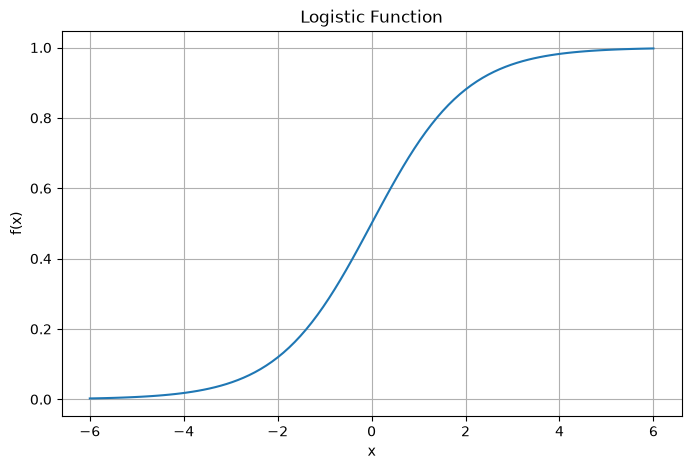

In [12]:
# put your code here
def logistic_function(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-6, 6, 100)
y = logistic_function(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Logistic Function")
plt.grid(True)
plt.show()

What is interesting about that curve is that all values of x are mapped into the range for y of 0.0-1.0. Assuming you have a binary classifier, that is one that only has two class labels, that is the mapping you want: all combination of features map into the two class labels 0, or 1. Moreover, the graph looks a lot like a [cumulative probability distribution](https://en.wikipedia.org/wiki/Cumulative_distribution_function). The probability that a set of features is of class 1 is 1 to the right and 0 to the left. As you watched in the pre-class video, this is the basis for logistic regression.

It's considered a regression because the "x" in our logisitic function is actually going to be a regression equation, such that

$$ fn= b_{0} + b_{1}x_{1} + b_{2}x_{2} + \ldots  $$

for as many terms as we like and the new logistic function

$$ f(x) = \frac{e^{fn(x))}} {1+e^{fn(x)} }  \equiv \frac{1}{1+e^{-fn(x)} } $$

Logisitic classification tries to find the values for the parameters $b_{i}$ that gives maximal performance on training, and hopefully testing. Let's let `statsmodels` do that.

We are going to use all the training data from above and train a logistic regression. It is similar to what we did before with regular regression.

Note, very importantly, the use of `sm.add_constant` on the training vectors. We talked about that when we did OLS in statsmodels. That column of constant is what the $b_{0}$ or intercept will train against. We need that column to get an intercept. (Note that this code requires that you used `train_labels` and `train_vectors` when you did the train-test split earlier)

In [13]:
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
result = logit_model.fit()
print(result.summary() )

Optimization terminated successfully.
         Current function value: 0.090955
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.8597
Time:                        11:49:35   Log-Likelihood:                -47.660
converged:                       True   LL-Null:                       -339.63
Covariance Type:            nonrobust   LLR p-value:                5.843e-120
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -9.1917      1.143     -8.042      0.000   

The "Pseudo R-squ" is the equivalent (mostly) of the R-squared value in Linear regression that we looked for before. It ranges from 0 (poor fit) to 1 (perfect fit). The P values under "P > |z|" are measures of significance. The null hypothesis is that the restricted model (say a constant value for `fn`) performs better and a low p-value suggests that we can reject this hypothesis and prefer the full model over the null model (I.e., LOW $P$-VALUE IS GOOD). This is similar to the F-test for linear regression.

&#9989; **Do This**: Based on the results from above, remove the low-performing columns and then recreate the training and testing sets and run it again. Display the summary.

In [15]:
# put your code here
p_values = result.pvalues.drop("const")
display(p_values.sort_values())

good_features = p_values[p_values < 0.05].index.tolist()
print("Good features:", good_features)

features_reduced = features[good_features]

train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features_reduced,
    class_labels,
    test_size=0.25,
    random_state=1
)

logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))
logit_result = logit_model.fit()

print(logit_result.summary())
# Credit: ChatGPT 5.2 07/23/2026. 
# Asked I'm having error with this problem, can you explain it to me?

bare_nuclei                    0.000009
clump_thickness                0.003509
bland_chromatin                0.019246
uniformity_cell_shape          0.179380
mitoses                        0.185040
single_epithelial_cell_size    0.303854
normal_nucleoli                0.364547
marginal_adhesion              0.475397
uniformity_cell_size           0.728631
dtype: float64

Good features: ['clump_thickness', 'bare_nuclei', 'bland_chromatin']
Optimization terminated successfully.
         Current function value: 0.112080
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                  524
Model:                          Logit   Df Residuals:                      520
Method:                           MLE   Df Model:                            3
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.8271
Time:                        11:51:21   Log-Likelihood:                -58.730
converged:                       True   LL-Null:                       -339.63
Covariance Type:            nonrobust   LLR p-value:                1.920e-121
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -9.4294   

&#9989; **Question:** How do the fits of the full model and the reduced model compare? What evidence are you using to make compare these two fits?

<font size=+3>&#9998;</font> Reduced model fits about as well as the full model if the Pseudo R-squared is close to the full model. I am comparing the Pseudo R-squared values and the p-values. The reduced model is simpler because it removes weaker features.

### 2.2 What exactly is this model?

The following code will display the final equation for the model you just fit. You should be able to see the coefficients that were learned with the `logit_model.summary()` command above and these are the coefficients in the equation. The equation is the same as the one we had for linear regression, except that it is being fed into the logistic function.

In [16]:
def logit_equation(result, prob_form=True):
    """
    Build a string for the logistic regression equation from a statsmodels Logit result.
    If prob_form is True:  y = 1 / (1 + exp(-(b0 + ...)))
    If prob_form is False: log(p/(1-p)) = b0 + ...
    """
    params = result.params
    if 'const' not in params.index:
        raise ValueError("Model must include a constant term named 'const'.")

    intercept = params['const']
    coefs = params.drop('const')

    terms = [f"{intercept:.2f}"]
    for name, coef in coefs.items():
        sign = " + " if coef >= 0 else " - "
        terms.append(f"{sign}{abs(coef):.2f}*{name}")
    linear_part = "".join(terms)

    if prob_form:
        eq = f"y = 1 / (1 + np.exp(-({linear_part})))"
    else:
        eq = f"log(p/(1-p)) = {linear_part}"

    return eq

# Source:  Perplexity. Accessed March 13, 2026 from https://www.perplexity.ai/.  Prompt Chain: "Logistic regression equation helper for Wisconsin breast cancer dataset."

# You may need to edit the code below to match the name of your fitted model result variable
print(logit_equation(logit_result, prob_form=True))

y = 1 / (1 + np.exp(-(-9.43 + 0.80*clump_thickness + 0.55*bare_nuclei + 0.73*bland_chromatin)))


&#9989; **Do This**: Confirm that the coefficients in the equation above match the coefficients in the summary above.  How many unknown (free) parameters were in the model?  In other words, how many coefficients were learned by the model?



In [18]:
print("Number of learned coefficients:", len(logit_result.params))
print(logit_result.params)

print("Coefficients in the equation match the coefficients in the summary.")

Number of learned coefficients: 4
const             -9.429423
clump_thickness    0.801461
bare_nuclei        0.545369
bland_chromatin    0.733414
dtype: float64
Coefficients in the equation match the coefficients in the summary.


### 2.3 How good is the model?

There are a number of ways that we can check the performance of our model and we will continue new ways throughout the semester. The major difference in the standard statistics approach and supervised learning approaches is that we test our models using the data that we held out: "the testing data." 

That is, we will use our classifier model to make predictions from the test features and we can then compare those predictions to actual test labels. To test accuracy, we can use the output of the `.fit()` method of the model to predict how well the classifier works on the test data (the data it was not trained on). Conveniently that is the `.predict()` method and, again, we use it on the result of the `.fit()`. 

**Note:** The output from `.predict()` is not a 0/1 value as the test labels are, but rather a fraction between 0 and 1 indicating how likely each entry is to be one class or another. We can make the assumption that anything greater than 0.5 would be a 1 class and anything less than 0.5 would be a 0 class. 

&#9989; **Do This**: do the following:
- use the `.predict()` method (look up the documentation as necessary) to create the predicted labels using the test input
- convert the output of the `.predict()` method to the 0/1 class values of the test labels
- print the resulting predicted class values of the test labels

In [19]:
# put your code here
predicted_probs = logit_result.predict(sm.add_constant(test_vectors))

predicted_labels = (predicted_probs > 0.5).astype(int)

print(predicted_labels)

584    0
417    0
606    0
349    1
134    0
      ..
116    1
488    0
285    1
95     0
609    0
Length: 175, dtype: int64


One of the first metrics we will use in determining how well a machine learning model is working is the "accuracy score", which compares the predictions our model made for the test labels and the actual test labels. This score is one of many metrics we can use and is included in `sklearn.metrics` as (surprise) `accuracy_score()`. Here's the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score) on `accuracy_score`.

&#9989; **Do This**: Using the predicted 0/1 labels you just created:
- Use the `sklearn.metrics` we imported at the top and run the `accuracy_score` on the 0/1 predicted label and the test labels.
- Print your accuracy result

In [20]:
# put your code here
accuracy = metrics.accuracy_score(test_labels, predicted_labels)

print("Accuracy:", accuracy)

Accuracy: 0.96


&#9989; **Question:** How well did your model predict the test class labels? Given what you learned in the pre-class assignment about false positives and false negatives, what other questions should we ask about the accuracy of our model?

<font size=+3>&#9998;</font> I guess model predicted the test labels pretty well if the accuracy score is high. However, accuracy does not tell us everything. We should also ask how many false positives and false negatives the model made.

### Confusion matrix (Time Permitting)

Display a graphical version of the confusion matrix that summarizes the true positives, true negatives, false positives, and false negatives for the predicted labels compared to the actual test labels.  This is among the common way to evaluate the performance of a binary classification model.  You can use `sklearn.metrics.confusion_matrix` for this.  What do the values in the confusion matrix tell you about the performance of your model?

[[116   2]
 [  5  52]]


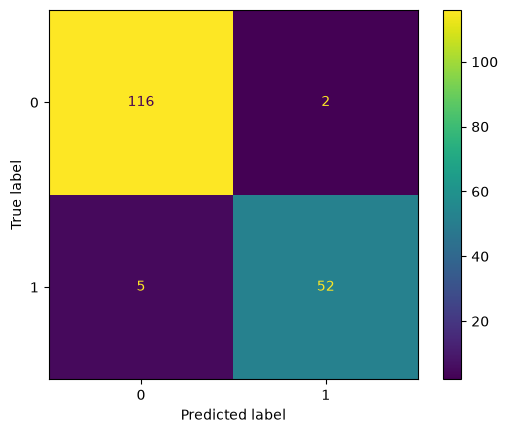

In [21]:
# put your code here
confusion = metrics.confusion_matrix(test_labels, predicted_labels)

print(confusion)

display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion)
display.plot()
plt.show()

- I think confusion matrix shows how many predictions were correct and incorrect. It helps to see true positives, true negatives, false positives, and false negatives.

-----
### Congratulations, we're done!

Now, you just need to submit this assignment by uploading it to the course <a href="https://d2l.msu.edu/">Desire2Learn</a> web page for today's submission folder (Don't forget to add your names in the first cell).


&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University

<!-- 9/16/2024 -->